<a href="https://colab.research.google.com/github/evandwh/actuarial-projects/blob/main/premium_calculation/Mini_Insurance_Pricing_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mini-Insurance Auto Insurance Pricing Model

First, we need to install openml to access the data we need.

In [ ]:
!pip install openml

Next, we need to install the necessary modules and access the desired dataset.

In [4]:
import pandas as pd
import openml
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np


dataset = openml.datasets.get_dataset(43593)

We want to switch our data into a dataframe so that it is easier to work with in python.

In [5]:
X, y, categorical, feature_names = dataset.get_data(
    target=dataset.default_target_attribute,
    dataset_format ="dataframe"
)

df = pd.concat([X, y], axis=1)

df.head()


,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


To get an idea of the variables we are working with and their destributions, we run the describe method. We will mostly be focused on four variables:

ClaimNb - Claim Number

Exposure

VehAge - How old the vehicle is.

DrivAge - Age of the driver.

In [6]:
df.describe()

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In this data set, the driver's ages range from 18 - 100 years old with an average of 45.5 years old. The vehicle ages range from 0 to 100, with a mean of approximately 7 years. I am scepticle about data points of 100 for both the VehAge and DrivAge. This might require further attention.

In [15]:
df['ClaimRate'] = df['ClaimNb'] / df['Exposure']
df.head()

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimRate
0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82,10.000000
1,1,0.77,D,5,0,55,50,B12,Regular,1217,R82,1.298701
2,1,0.75,B,6,2,52,50,B12,Diesel,54,R22,1.333333
3,1,0.09,B,7,0,46,50,B12,Diesel,76,R72,11.111111
4,1,0.84,B,7,0,46,50,B12,Diesel,76,R72,1.190476


In order to better investigate how ofter claims come in for some of the individuals in the dataset, we created a new variable `ClaimRate` which is the number of claims divided by the exposure time. This essentially, tells us how many "claims" would be made on the individual per calendar year.

## Age investigation

One of the variables that we are intersted in a predictor of an insurance claim is the Driver Age. Young drivers and older drivers have higher premiums normally for auto insurance. Let's investigate to see if we can see why.

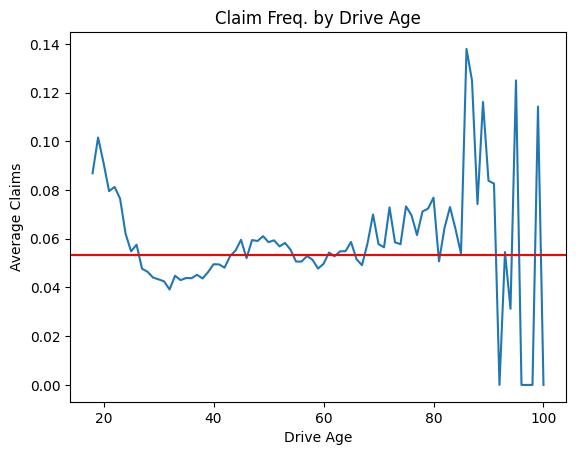

In [ ]:
df.groupby('DrivAge')['ClaimNb'].mean().plot()
plt.axhline(y=df['ClaimNb'].mean(), color='r', linestyle='-')
plt.title("Claim Freq. by Drive Age")
plt.xlabel("Drive Age")
plt.ylabel("Average Claims")
plt.show()

In [19]:
mean_claimrate = df['ClaimRate'].mean()
print(mean_claimrate)

0.2639639532452398


The average rate of claims made per individual is 0.264 per year.

In [17]:
mean_claim_age = df.groupby('DrivAge')['ClaimRate'].mean()

for _ in mean_claim_age.items():
    print(_)

(18, 0.7007203634400573)
(19, 0.4675578918009895)
(20, 0.489617813920003)
(21, 0.4417365749613986)
(22, 0.4187632809887918)
(23, 0.6096713201008032)
(24, 0.2770812861525207)
(25, 0.2589094632593073)
(26, 0.4032887474099324)
(27, 0.29762536214856417)
(28, 0.3077977972103743)
(29, 0.1857408027530828)
(30, 0.20135587927337154)
(31, 0.22684679705624528)
(32, 0.20401768612730864)
(33, 0.25967507354830033)
(34, 0.20334063795820911)
(35, 0.23790840956421216)
(36, 0.28169126590505067)
(37, 0.2186791396863286)
(38, 0.22831251259527266)
(39, 0.28482035671267014)
(40, 0.2901699781562242)
(41, 0.20971622990202718)
(42, 0.22220974837806676)
(43, 0.25462630432031463)
(44, 0.22411037947541343)
(45, 0.26542138177667457)
(46, 0.24528228709377844)
(47, 0.23716782033131611)
(48, 0.3992291448096583)
(49, 0.32522515945228325)
(50, 0.29677010283118765)
(51, 0.30282295685631627)
(52, 0.25328985075761346)
(53, 0.33167176883061195)
(54, 0.2786775208666426)
(55, 0.24514321003406744)
(56, 0.2626823166043082)
(57

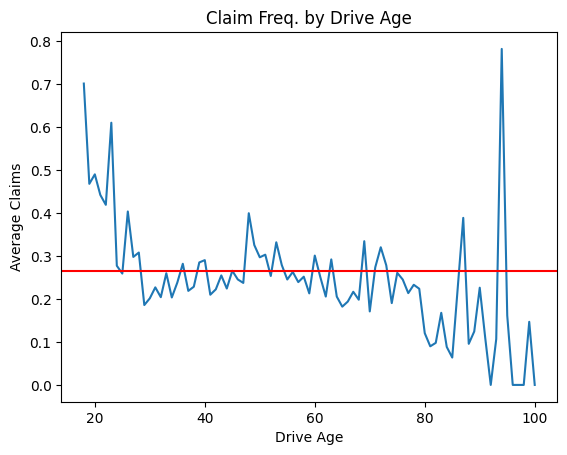

In [26]:
df.groupby('DrivAge')['ClaimRate'].mean().plot()
plt.axhline(y=df['ClaimRate'].mean(), color='r', linestyle='-')
plt.title("Claim Rate by Drive Age")
plt.xlabel("Drive Age")
plt.ylabel("Average Claim Rate")
plt.show()

Here, we can see the ClaimRate of each age group. Some ages have 0 claims in the dataset. This is most likely do to a lack a data on individuals in those ages. I would like to see the breakdown in the age of drivers in this area to see how often a certain aged person is driving on the road.

In [20]:
for _ in mean_claim_age.items():
    if _[1] > mean_claimrate:
        print(_)

(18, 0.7007203634400573)
(19, 0.4675578918009895)
(20, 0.489617813920003)
(21, 0.4417365749613986)
(22, 0.4187632809887918)
(23, 0.6096713201008032)
(24, 0.2770812861525207)
(26, 0.4032887474099324)
(27, 0.29762536214856417)
(28, 0.3077977972103743)
(36, 0.28169126590505067)
(39, 0.28482035671267014)
(40, 0.2901699781562242)
(45, 0.26542138177667457)
(48, 0.3992291448096583)
(49, 0.32522515945228325)
(50, 0.29677010283118765)
(51, 0.30282295685631627)
(53, 0.33167176883061195)
(54, 0.2786775208666426)
(60, 0.30076448709861675)
(63, 0.2918119164340811)
(69, 0.3341671321667395)
(71, 0.27349489060490906)
(72, 0.32005824046041675)
(73, 0.27806243979821965)
(87, 0.3884513748662256)
(94, 0.78125)


Here, we can see all of the ages that have a claim rate greater than the average claim rate in our data set. Every age from 18-28 had a greater mean except the age of 25. Then only ages in the 30s that have a mean greater than the overall average were the ages of 36 and 39.

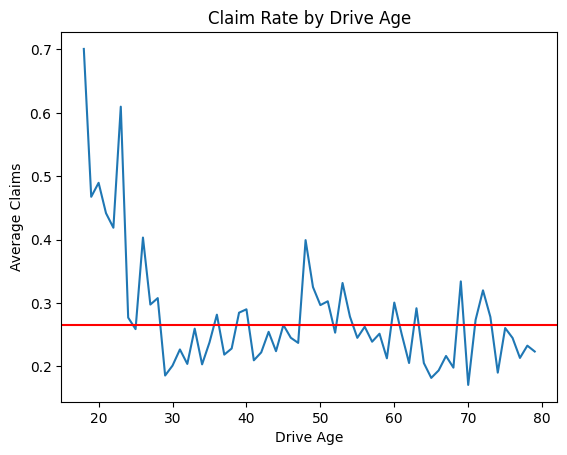

In [27]:
df_age_u80 = df[df['DrivAge'] < 80]


df_age_u80.groupby('DrivAge')['ClaimRate'].mean().plot()
plt.axhline(y=df_age_u80['ClaimRate'].mean(), color='r', linestyle='-')
plt.title("Claim Rate by Drive Age")
plt.xlabel("Drive Age")
plt.ylabel("Average Claims")
plt.show()

If we remove those drivers over the age of 80 and repeat the process, you can see how much more frequent young drivers tend to have claims over older drivers. Around the age of 50, it seems to spike again.

## Vehicle Age Investigation

Next, we will investigate vehicle age in a similar fashion to what we did with driver age.

In [23]:
mean_claim_vehage = df.groupby('VehAge')['ClaimRate'].mean()

for _ in mean_claim_vehage.items():
    print(_)

(0, 1.1412833540407648)
(1, 0.1843544697228591)
(2, 0.1477759103581773)
(3, 0.1732723881007568)
(4, 0.17963475962037015)
(5, 0.21850068369518882)
(6, 0.21874016462077003)
(7, 0.20128342834418472)
(8, 0.19653704054380924)
(9, 0.21719909914736274)
(10, 0.22896197032837992)
(11, 0.1786196981781554)
(12, 0.16719869961072523)
(13, 0.14871736162483298)
(14, 0.1516593658366718)
(15, 0.15851947256029955)
(16, 0.21671734785031957)
(17, 0.15433127519287226)
(18, 0.11504451566049344)
(19, 0.09845295245777533)
(20, 0.16267645370456602)
(21, 0.07584278559637245)
(22, 0.14568614589841086)
(23, 0.07079860857896993)
(24, 0.06021780641402667)
(25, 0.08152190610255836)
(26, 0.2156888335875373)
(27, 0.6317214002165283)
(28, 0.0534228938990183)
(29, 0.025355871886120998)
(30, 0.08414789067939844)
(31, 0.030163385002094683)
(32, 0.0415499533146592)
(33, 0.17460317460317462)
(34, 0.0)
(35, 0.17850606268588426)
(36, 0.10540043379183482)
(37, 0.0425531914893617)
(38, 0.0)
(39, 0.10451612903225808)
(40, 0.0)
(

In [24]:
for _ in mean_claim_vehage.items():
    if _[1] > mean_claimrate:
        print(_)

(0, 1.1412833540407648)
(27, 0.6317214002165283)
(42, 0.32051282051282054)
(69, 0.49019607843137253)
(84, 1.0)


This shows that there is not a trend among vehicle age and claims. The vast majority seems to be claims that happen with vehicles that were bought that calendar year. I'm also very interested in the vehicle aged 84 years that had a claim!

Ultimately, I don't believe that this shows us too much valuable information except that brand new vehicles have a lot of claims!


# Predicting Claims

We're going to look at three different models. The first will use DrivAge, VehAge, and VehPower, but will not offset based on Exposure.

In [61]:
x = df[['DrivAge', 'VehAge', 'VehPower']]
x = sm.add_constant(x)
y = df['ClaimNb']

model1 = sm.GLM(y, x, family=sm.families.Poisson()).fit()
print(model1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678009
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4329e+05
Date:                Tue, 17 Mar 2026   Deviance:                   2.1725e+05
Time:                        03:42:09   Pearson chi2:                 7.34e+05
No. Iterations:                     7   Pseudo R-squ. (CS):          0.0006638
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8927      0.025   -114.601      0.0

Now we will make a model with those three variables, but will offset for exposure. We cannot really predict based on exposure, as that is the time it may take a claim to happen, but we do not want to ignore it completely. Offsetting lets use the value as a scale to calculate more a claim rate type value.

In [62]:
model2 = sm.GLM(
    y,
    x,
    family=sm.families.Poisson(),
    offset = np.log(df['Exposure'])
).fit()

print(model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678009
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4599e+05
Date:                Tue, 17 Mar 2026   Deviance:                   2.2266e+05
Time:                        03:42:16   Pearson chi2:                 1.84e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.002683
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8042      0.026    -70.723      0.0

 Now, we will take VehPower out of the mix and only use Driver Age and Vehichle Age as the two predictor variables.

In [63]:
X = df[['DrivAge', 'VehAge']]
X = sm.add_constant(X)

y = df['ClaimNb']

model3 = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=np.log(df['Exposure'])
).fit()

print(model3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   678010
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4599e+05
Date:                Tue, 17 Mar 2026   Deviance:                   2.2266e+05
Time:                        03:42:21   Pearson chi2:                 1.84e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.002675
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7668      0.019    -90.951      0.0

In [67]:
examples = pd.DataFrame({
    'DrivAge': [22, 35, 50, 25],
    'VehAge': [15, 5, 10, 0],
    'VehPower': [5, 6, 7, 5]
})

# Add constant (required for statsmodels)
examples = sm.add_constant(examples)

predictions1 = model1.predict(examples)
predictions2 = model2.predict(examples)


print(predictions1 , "\n")
print(predictions2)


0    0.043253
1    0.053296
2    0.050645
3    0.056995
dtype: float64 

0    0.081861
1    0.116026
2    0.088012
3    0.149063
dtype: float64


At this point, I cannot explain the difference in these values too much, but you can see the same trend in both predictions. I believe the second model predicts the claim rate.

In [73]:
examples['Predicted_Claims'] = predictions2
print(examples)

   const  DrivAge  VehAge  VehPower  Predicted_Claims  Expected_Loss
0    1.0       22      15         5          0.081861     409.305273
1    1.0       35       5         6          0.116026     580.128286
2    1.0       50      10         7          0.088012     440.057674
3    1.0       25       0         5          0.149063     745.316138


Admittedly, Severity, expense ratio, and profit ratio are not values that I know for common insurance policies like this. I used AI to help pick good values for those three values.

In [75]:
severity = 5000

examples['Expected_Loss'] = examples['Predicted_Claims'] * severity

expense_ratio = 0.30
profit_ratio = 0.10

examples['Premium'] = (
    examples['Expected_Loss'] /
    (1 - expense_ratio - profit_ratio)
)

print(examples)

   const  DrivAge  VehAge  VehPower  Predicted_Claims  Expected_Loss  \
0    1.0       22      15         5          0.081861     409.305273   
1    1.0       35       5         6          0.116026     580.128286   
2    1.0       50      10         7          0.088012     440.057674   
3    1.0       25       0         5          0.149063     745.316138   

       Premium  
0   682.175455  
1   966.880477  
2   733.429456  
3  1242.193564  


In [77]:
examples2 = pd.DataFrame({
    'DrivAge': [22, 35, 50, 25],
    'VehAge': [15, 5, 10, 0],
})

# Add constant (required for statsmodels)
examples2 = sm.add_constant(examples2)

predictions3 = model3.predict(examples2)
examples2['Predicted_Claims'] = predictions3


examples2['Expected_Loss'] = examples2['Predicted_Claims'] * severity

examples2['Premium'] = (
    examples2['Expected_Loss'] /
    (1 - expense_ratio - profit_ratio)
)

print(examples2)

   const  DrivAge  VehAge  Predicted_Claims  Expected_Loss      Premium
0    1.0       22      15          0.082484     412.420694   687.367824
1    1.0       35       5          0.116286     581.427580   969.045966
2    1.0       50      10          0.087695     438.475526   730.792543
3    1.0       25       0          0.150286     751.431612  1252.386020


Based on the projected premiums, it appears that the value for Vehicle Power did not make much impact. The largest difference in the projected premiums was $10 from one prediction to the next. I would like to keep vehicle age constant for different drivers ages and see what the results are. Perhaps in a future study.

#Conclusion

Investigating this data was a lot of fun. It helped me learn several different things that are using to factor insurance premiums for auto drivers. I need to learn more about the severity, expense ratio, and profit ratio, as I am not sure how those are calculated.

## Future Projects


*   I would like to build a machine learning algorithm to use a set of the data to train the model and test the rest of the data.
*   I would like to turn this into a mathematical formula where it is easier to plug in specific values.
*  I would like to keep age constant and change vehicle age and power to see how much it changes the premium cost.

